In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [3]:
df_df40 = pd.read_csv("analysis/metrics_df40.csv", index_col=0)

df_fs_auc = df_df40[["model_name", "test_dataset", "train_dataset", "frame_auc", "video_auc"]]
df_fs_auc = df_fs_auc[df_fs_auc["test_dataset"] == "FSAll_cdf"]
df_fs_auc = df_fs_auc.sort_values(by="video_auc", ascending=False).reset_index(drop=True)

df_fr_auc = df_df40[["model_name", "test_dataset", "train_dataset", "frame_auc", "video_auc"]]
df_fr_auc = df_fr_auc[df_fr_auc["test_dataset"] == "FRAll_cdf"]
df_fr_auc = df_fr_auc.sort_values(by="video_auc", ascending=False).reset_index(drop=True)

df_both_auc = df_df40.groupby(['model_name', 'train_dataset'])['video_auc'].mean().reset_index().sort_values(by="video_auc", ascending=False).reset_index(drop=True)
df_both_auc = df_both_auc.rename(columns={'video_auc': 'average_video_auc'})

In [4]:
df_pivot = df_df40.pivot_table(
    values='video_auc', 
    index=['model_name', 'train_dataset'], 
    columns='test_dataset'
).reset_index()

df_pivot['diff_video_auc'] = df_pivot['FSAll_cdf'] - df_pivot['FRAll_cdf']

df_diff = df_pivot[['model_name', 'train_dataset', 'diff_video_auc']]

In [5]:
palette = {
    'ff-orig': '#4C72B0',
    'df40-fr-ff': '#C44E52',
    'df40-fs-ff':'#D5BB67',
    'df40-all-ff': '#55A868'
}

train_datasets_order = ["df40-all-ff", "df40-fs-ff", "df40-fr-ff", "ff-orig"]

In [6]:
df_diff['model_train_label'] = df_diff['model_name'] + " (" + df_diff['train_dataset'] + ")"

df_diff_clean = df_diff[['model_train_label', 'diff_video_auc']]
df_diff_clean = df_diff_clean.sort_values('diff_video_auc', ascending=False)

/tmp/ipykernel_18377/4293370535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_diff['model_train_label'] = df_diff['model_name'] + " (" + df_diff['train_dataset'] + ")"


/tmp/ipykernel_18377/2669727988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


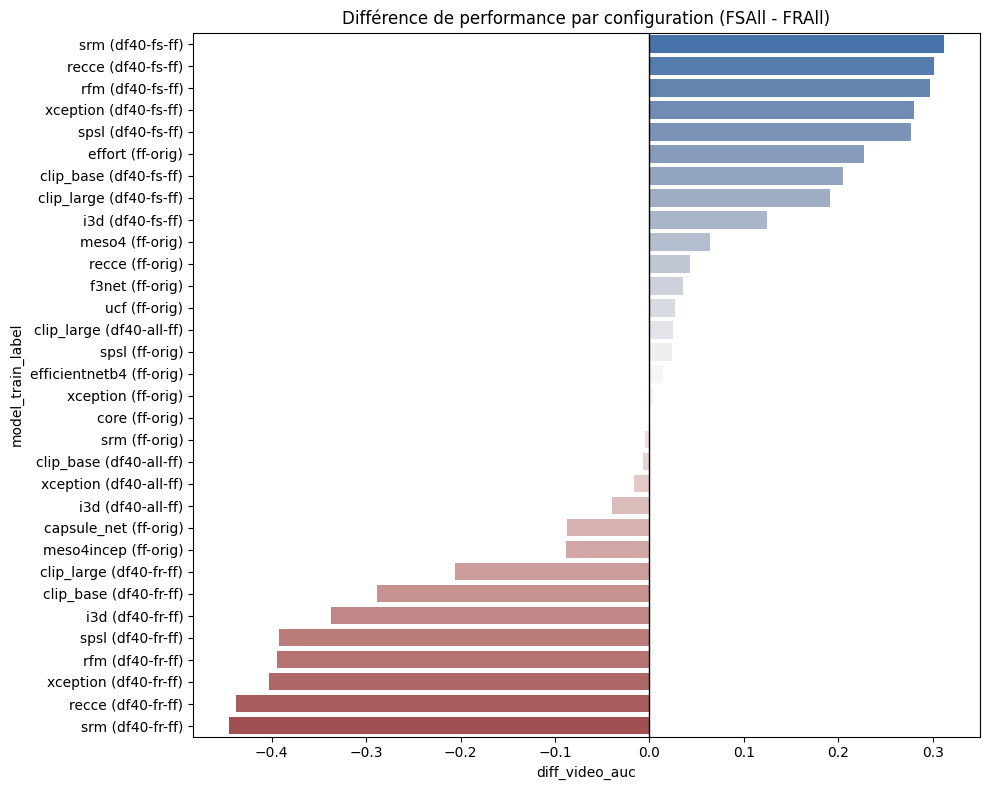

In [7]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_diff_clean,
    x='diff_video_auc',
    y='model_train_label',
    palette='vlag'
)

plt.axvline(0, color='black', lw=1)
plt.title('Différence de performance par configuration (FSAll - FRAll)')
plt.tight_layout()
plt.show()

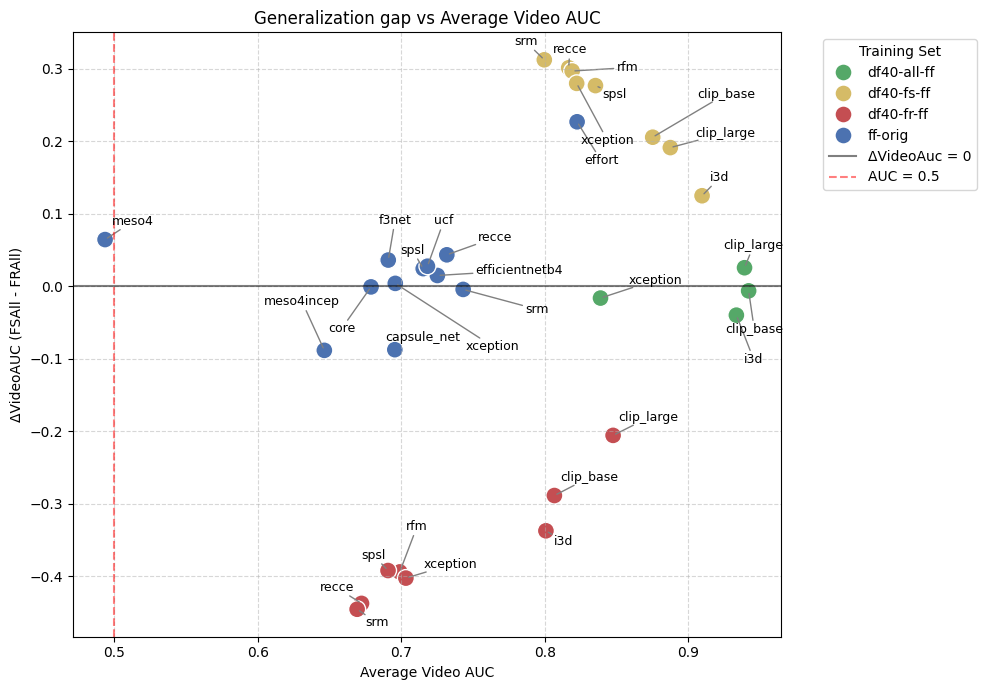

In [8]:
# On part du principe que df contient les colonnes : 
# model_name, train_dataset, test_dataset, video_auc

# 1. On "pivote" le tableau pour avoir les datasets de test en colonnes
df_pivot = df_df40.pivot_table(
    values='video_auc', 
    index=['model_name', 'train_dataset'], 
    columns='test_dataset'
).reset_index()

# 2. On calcule les deux métriques qui nous intéressent (X et Y)
df_pivot['average_video_auc'] = df_pivot[['FSAll_cdf', 'FRAll_cdf']].mean(axis=1)
df_pivot['diff_video_auc']    = df_pivot['FSAll_cdf'] - df_pivot['FRAll_cdf']

# 3. Création du graphique
plt.figure(figsize=(10, 7))

# Le Scatter Plot (nuage de points)
sns.scatterplot(
    data=df_pivot,
    x='average_video_auc',
    y='diff_video_auc',
    hue='train_dataset', # Couleur selon le set d'entraînement
    hue_order= train_datasets_order,
    s=150,               # Taille des points
    palette=palette     # On garde ta palette
)

labels = []

for i in range(len(df_pivot)):
    texte = plt.text(
        x=df_pivot['average_video_auc'][i], 
        y=df_pivot['diff_video_auc'][i], 
        s=df_pivot['model_name'][i],
        fontsize=9
    )
    labels.append(texte)

adjust_text(
    labels,
    force_explode=5,
    expand=(2,2),
    #force_text=100,
    arrowprops=dict(arrowstyle="-", color='gray', lw=1, alpha=1)
)

# 5. Lignes de référence cruciales pour la lecture
plt.axhline(0, color='black', linestyle='-', alpha=0.5, label='ΔVideoAuc = 0')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='AUC = 0.5')

# 6. Cosmétique
plt.title('Generalization gap vs Average Video AUC')
plt.xlabel('Average Video AUC')
plt.ylabel('ΔVideoAUC (FSAll - FRAll)')
plt.legend(title="Training Set", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

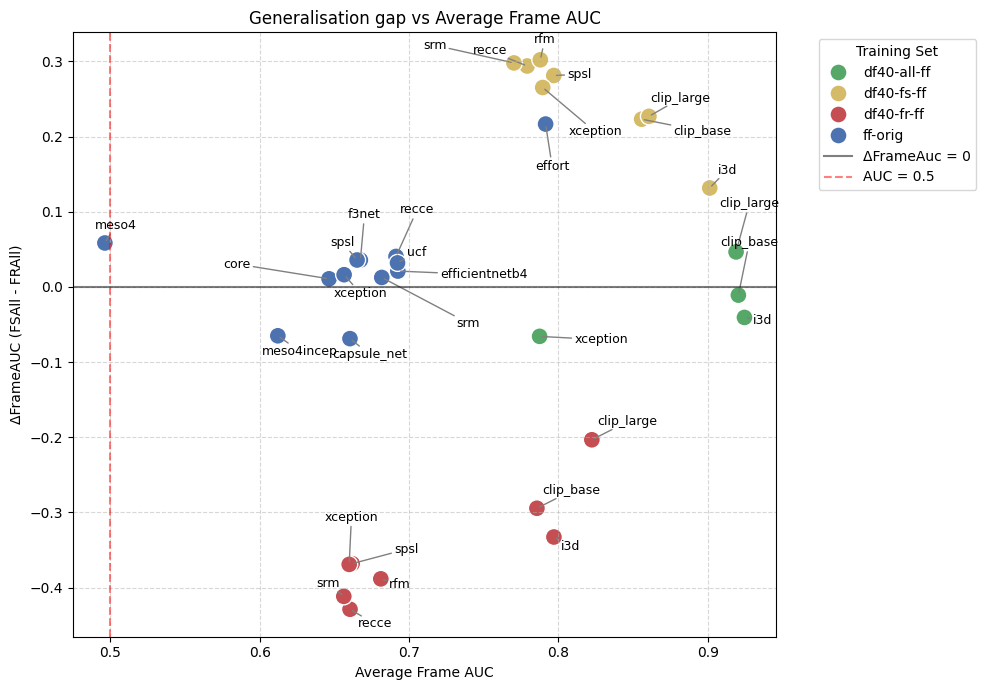

In [9]:
# On part du principe que df contient les colonnes : 
# model_name, train_dataset, test_dataset, video_auc

# 1. On "pivote" le tableau pour avoir les datasets de test en colonnes
df_pivot = df_df40.pivot_table(
    values='frame_auc', 
    index=['model_name', 'train_dataset'], 
    columns='test_dataset'
).reset_index()

# 2. On calcule les deux métriques qui nous intéressent (X et Y)
df_pivot['average_frame_auc'] = df_pivot[['FSAll_cdf', 'FRAll_cdf']].mean(axis=1)
df_pivot['diff_frame_auc']    = df_pivot['FSAll_cdf'] - df_pivot['FRAll_cdf']

# 3. Création du graphique
plt.figure(figsize=(10, 7))

# Le Scatter Plot (nuage de points)
sns.scatterplot(
    data=df_pivot,
    x='average_frame_auc',
    y='diff_frame_auc',
    hue='train_dataset', # Couleur selon le set d'entraînement
    hue_order= train_datasets_order,
    s=150,               # Taille des points
    palette=palette     # On garde ta palette
)

labels = []

for i in range(len(df_pivot)):
    texte = plt.text(
        x=df_pivot['average_frame_auc'][i], 
        y=df_pivot['diff_frame_auc'][i], 
        s=df_pivot['model_name'][i],
        fontsize=9
    )
    labels.append(texte)

adjust_text(
    labels,
    force_explode=5,
    expand=(2,2),
    #force_text=100,
    arrowprops=dict(arrowstyle="-", color='gray', lw=1, alpha=1)
)

# 5. Lignes de référence cruciales pour la lecture
plt.axhline(0, color='black', linestyle='-', alpha=0.5, label='ΔFrameAuc = 0')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='AUC = 0.5')

# 6. Cosmétique
plt.title('Generalisation gap vs Average Frame AUC')
plt.xlabel('Average Frame AUC')
plt.ylabel('ΔFrameAUC (FSAll - FRAll)')
plt.legend(title="Training Set", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [18]:
def show_bar_graph(df, x_col, title, xlabel):
    plt.figure(figsize=(10, 10))

    ax = sns.barplot(
        data=df, 
        x=x_col, 
        y=df.index, 
        hue='train_dataset',
        hue_order=train_datasets_order,
        orient='h',
        dodge=False,
        palette=palette,
    )

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['model_name'])

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Model')
    plt.xlim(0.4, 1.0)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend(title='Training Set')
    #plt.legend(title='Training Set', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

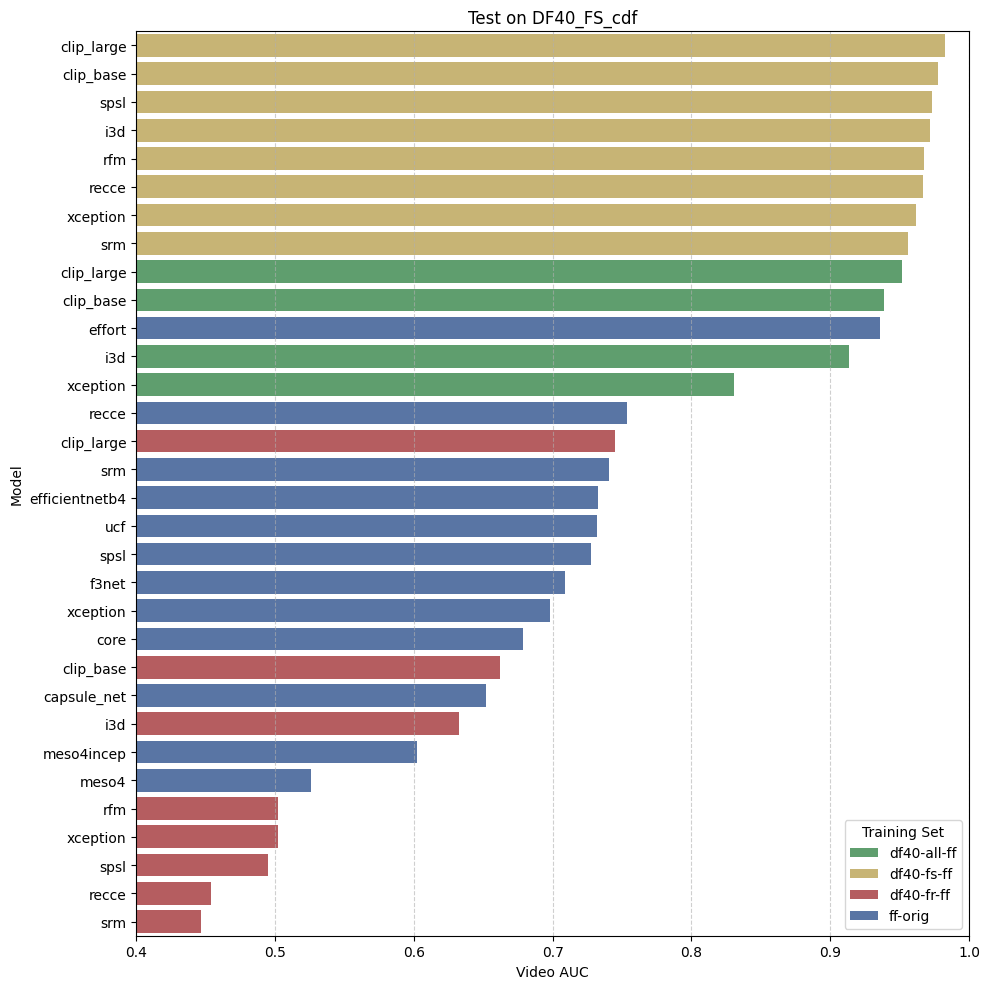

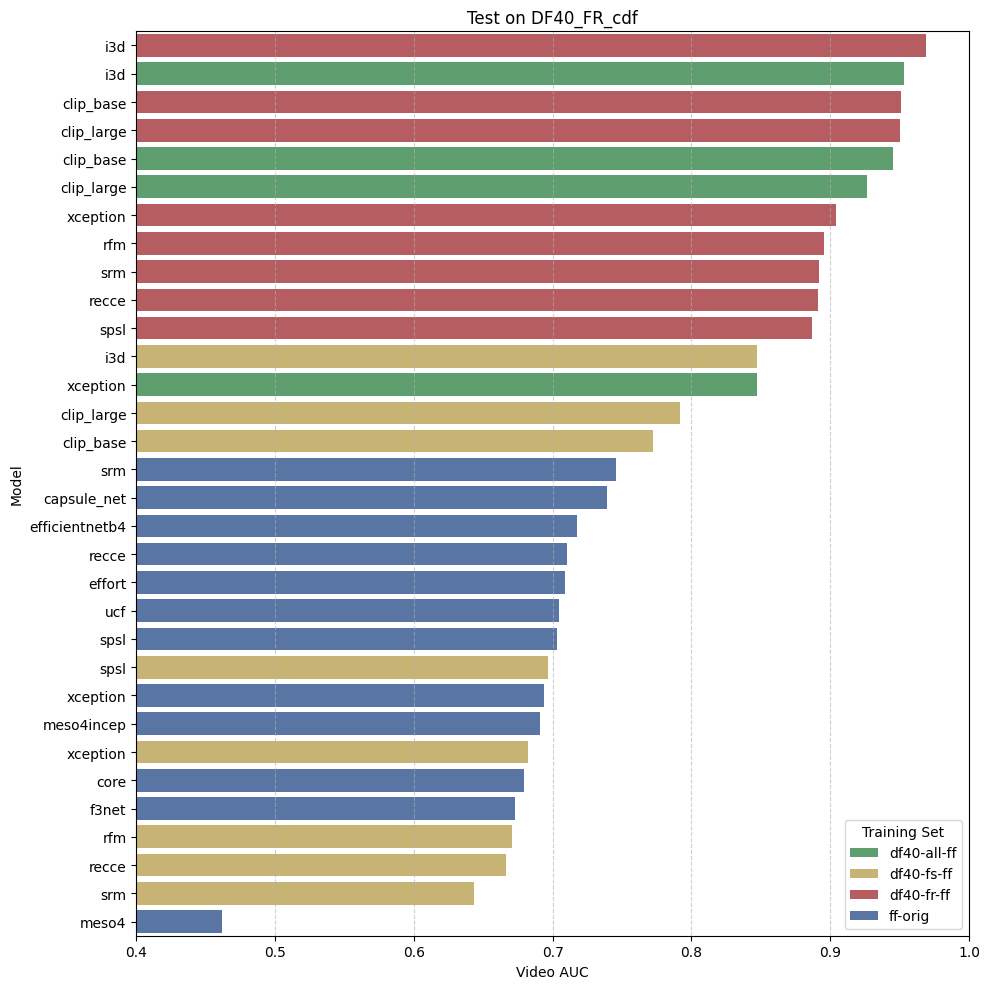

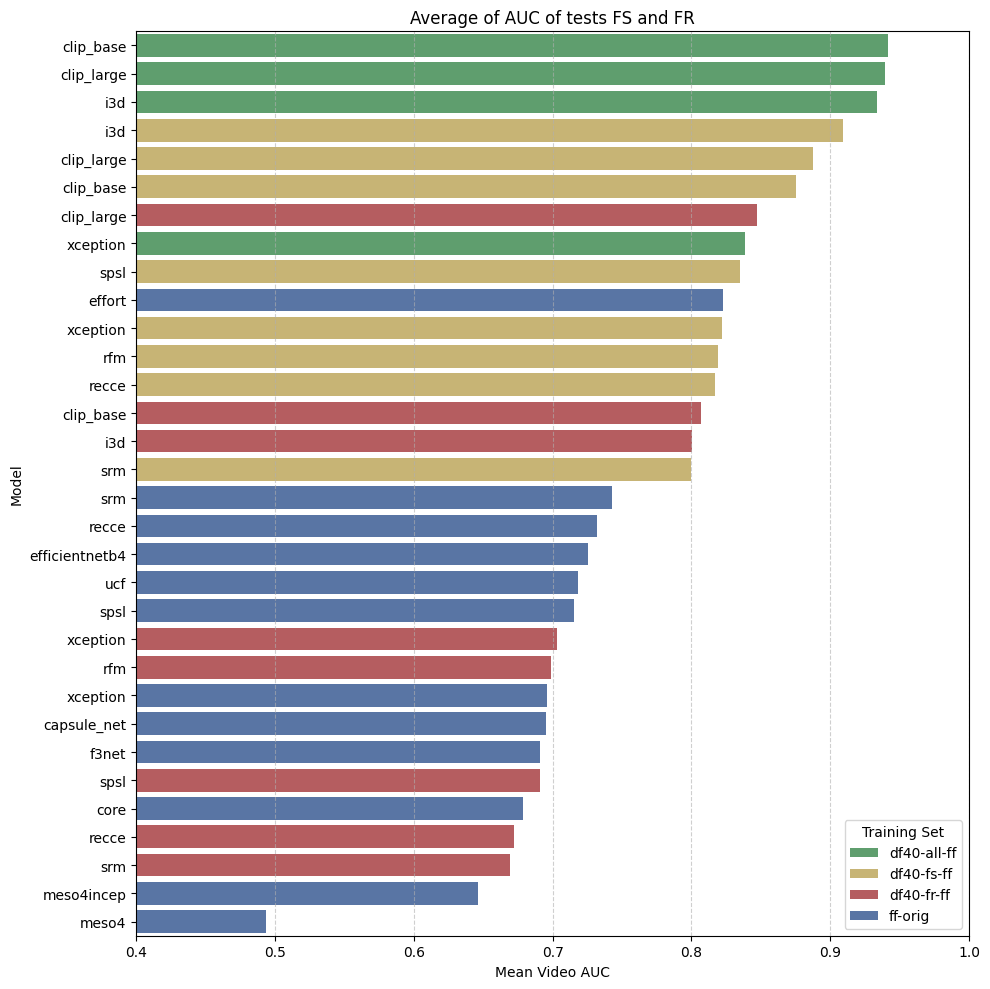

In [19]:
show_bar_graph(df_fs_auc, "video_auc", "Test on DF40_FS_cdf", "Video AUC")
show_bar_graph(df_fr_auc, "video_auc", "Test on DF40_FR_cdf", "Video AUC")
show_bar_graph(df_both_auc, "average_video_auc", "Average of AUC of tests FS and FR", "Mean Video AUC")

# ConfDF

In [12]:
df_confdf= pd.read_csv("analysis/metrics_confdf.csv", index_col=0)

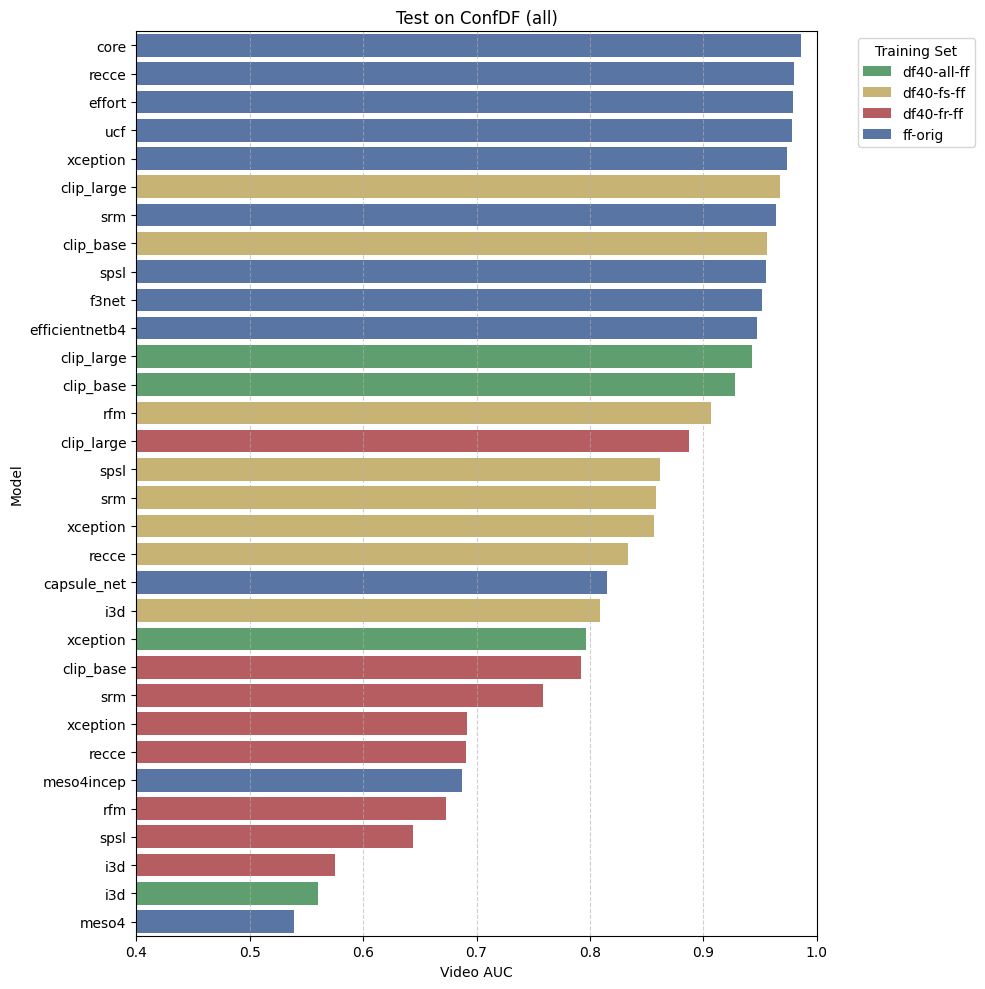

In [13]:
df_confdf_all = df_confdf[["model_name", "test_dataset", "train_dataset", "frame_auc", "video_auc"]]
df_confdf_all = df_confdf_all[df_confdf_all["test_dataset"] == "ConfDF_norm_v2_all"]
df_confdf_all = df_confdf_all.sort_values(by="video_auc", ascending=False).reset_index(drop=True)

show_bar_graph(df_confdf_all, "video_auc", "Test on ConfDF (all)", "Video AUC")

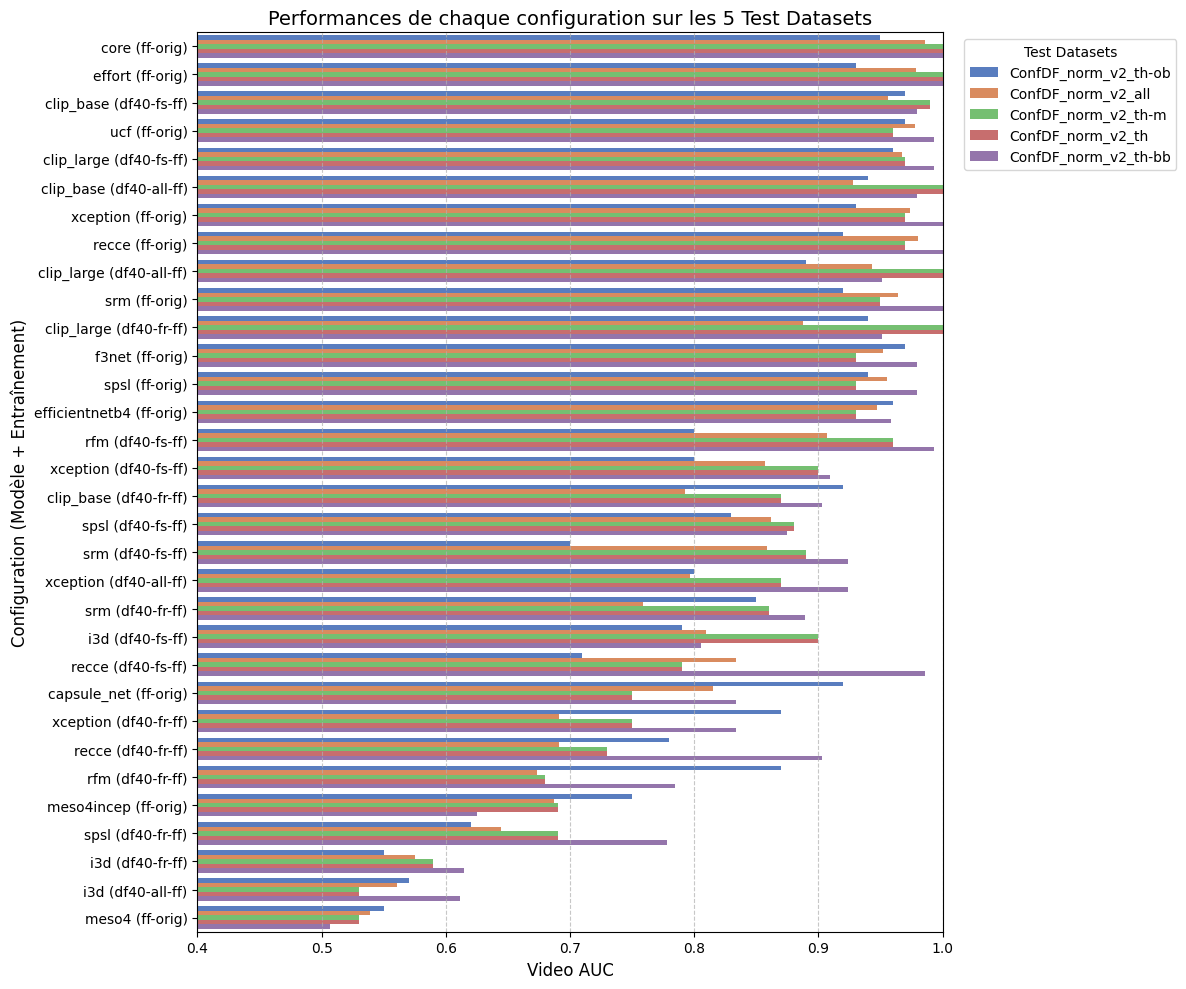

In [14]:
df_confdf['model_train_label'] = df_confdf['model_name'] + " (" + df_confdf['train_dataset'].str.replace('train_on_', '') + ")"

ordre_modeles = df_confdf.groupby('model_train_label')['video_auc'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 10))

sns.barplot(
    data=df_confdf,
    y='model_train_label',  
    x='video_auc',          
    hue='test_dataset',    
    order=ordre_modeles,    
    palette='muted'         
)

plt.title('Performances de chaque configuration sur les 5 Test Datasets', fontsize=14)
plt.xlabel('Video AUC', fontsize=12)
plt.ylabel('Configuration (Modèle + Entraînement)', fontsize=12)


plt.xlim(0.4, 1.0)

# On décale la légende à l'extérieur pour qu'elle ne cache pas les barres
plt.legend(title='Test Datasets', bbox_to_anchor=(1.02, 1), loc='upper left')

# On ajoute une grille verticale pour faciliter la lecture des scores
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()